## Settings and imports

In [1]:
import numpy as np
import pandas as pd
import os
import torch
import matplotlib.pyplot as plt
import string
from torch import nn
from torch.utils.data import Dataset, DataLoader
import sklearn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import normalize
import random

In [2]:
object_name = 'Documents_XVIII_century' # Books / Documents_XVIII_century

In [3]:
if object_name == 'Books':
    real_or_simulated = 'real' #simulated / real / all
    augmentation = False
    augmentation_weights = [0.9, 0.1]
    proportion_of_augmented = 0.25

keep_sample_together = False #Should all 15 slices from the same sample go together to the same set (train/test)?
if keep_sample_together:
    sample_together = 'sample_together'
else:
    sample_together = 'sample_split'
    
preprocessing_method = 'logarithm' # normalization / logarithm

columns_to_keep_inks = {
                        'Books': [
                                                 'Al_inks',
                                                 'S_inks',
                                                 'Cr_inks',
                                                 'Mn_inks',
                                                 'Co_inks',
                                                 'Cu_inks',
                                                 'Zn_inks',
                                                 'Pb_inks'],
    
                        'Documents_XVIII_century' : [
                                                 'Al_inks',
                                                 'S_inks',
                                                 'Cr_inks',
                                                 'Mn_inks',
                                                 'Co_inks',
                                                 'Cu_inks',
                                                 'Zn_inks',
                                                 'Pb_inks'
                                                            ],
    
                        'Konstytucja' : [
                                                 'Al',
                                                 'S',
                                                 'Cr',
                                                 'Mn',
                                                 'Co',
                                                 'Cu',
                                                 'Zn',
                                                 'Pb'
                                                            ]
    
                        }

columns_to_keep_inds = { 
                        'Books' : [
                            
                                                 'Al_inds',
                                                 'S_inds',
                                                 'Cr_inds',
                                                 'Mn_inds',
                                                 'Co_inds',
                                                 'Cu_inds',
                                                 'Zn_inds',
                                                 'Pb_inds'],
    
                        'Documents_XVIII_century' : [
                                                 'Al_inds',
                                                 'S_inds',
                                                 'Cr_inds',
                                                 'Mn_inds',
                                                 'Co_inds',
                                                 'Cu_inds',
                                                 'Zn_inds',
                                                 'Pb_inds'
                                                        ],
                        'Konstytucja' : []
    
                        }

In [4]:
data_path = {'Books' : '../data/DANE.xlsx',
             'Documents_XVIII_century' : '../data/Lipiec_2024.xlsx',
             'Konstytucja' : '../data/Lipiec_2024.xlsx'}

results_path = {'Books' : '../results/Books/',
                'Documents_XVIII_century' : '../results/Documents_XVIII_century/',
                'Konstytucja' : '../results/Konstytucja/'}

figures_path = {'Books' : '../results/visualisations/Books/',
                'Documents_XVIII_century' : '../results/visualisations/Documents_XVIII_century/',
                'Konstytucja': '../results/visualisations/Konstytucja/'}

models_path = {'Books' : '../models/Books/',
                'Documents_XVIII_century' : '../models/Documents_XVIII_century/',
                'Konstytucja' : '../models/Konstytucja/'}

1) próbki razem + trzymanie jakiegoś id
2) czyszczenie danych
3) train-test split
4) augmentacja
5) normalizacja
6) ocena jakości

## Loading the data

In [5]:
df = pd.ExcelFile(data_path[object_name])

if object_name == 'Books':
    if real_or_simulated == 'simulated':
        inks_df = df.parse('a.', header=0, index_col=0, usecols=list)[:1425] #inKs
        inds_df = df.parse('i.', header=0, index_col=0, usecols=list)[:1425]  #inDs
    elif real_or_simulated == 'real':
        inks_df = df.parse('a.', header=0, index_col=0, usecols=list)[1425:] #inKs
        inds_df = df.parse('i.', header=0, index_col=0, usecols=list)[1425:]  #inDs
    elif real_or_simulated == 'all':
        inks_df = df.parse('a.', header=0, index_col=0, usecols=list) #inKs
        inds_df = df.parse('i.', header=0, index_col=0, usecols=list) #inDs

elif object_name == 'Documents_XVIII_century':
    inks_df = df.parse('Arkusz1', header=0, usecols=range(2,29), skiprows=range(3931, 4742))
    inds_df = df.parse('Arkusz1', header=0, usecols=range(32,59), skiprows=range(3931, 4742))
    inds_df.columns = inks_df.columns

## Preprocessing

### Joining corresponding samples from inds and inks into one table

In [6]:
inks_df = inks_df.reset_index(drop=False)
inds_df = inds_df.reset_index(drop=False)
inDKs_df = inds_df.join(inks_df, how='inner', rsuffix='_inks', lsuffix='_inds')

In [7]:
# with pd.option_context("display.max_rows", inDKs_df.shape[0]):
#     display(inDKs_df[['nazwa próbki_inds', 'nazwa próbki_inks']][
#                 (inDKs_df['nazwa próbki_inds'].apply(
#                         lambda x: x[:4]) != inDKs_df['nazwa próbki_inks'].apply(
#                                         lambda x: x[:4]))
#                                                         ])

### Keeping track of the records from the same sample

In [8]:
inDKs_df['Sample_id'] = np.repeat(range(int(inDKs_df.shape[0]/15)), 15, axis=0)

In [9]:
# with pd.option_context("display.max_rows", inDKs_df.shape[0]):
#     display(inDKs_df)

### Removing some data

1. Let's keep only columns that we need.

To reduce the set of used elements run cell below. Then, instead of predicting 29 numbers, we will predict only 8. We will also use only 8 numbers as input.

In [10]:
inDKs_df = inDKs_df[columns_to_keep_inks[object_name] + columns_to_keep_inds[object_name] + ['Sample_id']]

2. Let's remove rows with missing values.

In [11]:
(inDKs_df.shape[0] - inDKs_df.dropna().shape[0])/inDKs_df.shape[0]

0.007888040712468193

In [12]:
inDKs_df.dropna(inplace=True)

### Train test split, datasets, dataloaders

In [13]:
if keep_sample_together:
    
    indices = list(inDKs_df['Sample_id'].unique())
    
    ind_train, ind_test = train_test_split(indices, test_size=0.2, random_state=1)
    ind_train, ind_val = train_test_split(ind_train, test_size=0.25, random_state=1)
    
    X_y_train = inDKs_df[inDKs_df['Sample_id'].apply(lambda x: x in ind_train)]
    X_y_val = inDKs_df[inDKs_df['Sample_id'].apply(lambda x: x in ind_val)]
    X_y_test = inDKs_df[inDKs_df['Sample_id'].apply(lambda x: x in ind_test)]
    
    X_y_train.reset_index(drop=True, inplace=True)
    X_y_val.reset_index(drop=True, inplace=True)
    X_y_test.reset_index(drop=True, inplace=True)

else:
    indices = list(range(int(inDKs_df.shape[0])))
    ind_train_all, ind_test_all = train_test_split(indices, test_size=0.2, random_state=1)
    ind_train_all, ind_val_all = train_test_split(ind_train_all, test_size=0.25, random_state=1)
    
    partition = {'train': ind_train_all,
             'val': ind_val_all,
            'test': ind_test_all}
    
    X_y_train = inDKs_df.iloc[partition['train'],:]
    X_y_val = inDKs_df.iloc[partition['val'],:]
    X_y_test = inDKs_df.iloc[partition['test'],:]
    
    X_y_train.reset_index(drop=True, inplace=True)
    X_y_val.reset_index(drop=True, inplace=True)
    X_y_test.reset_index(drop=True, inplace=True)

### Data augmentation

In [14]:
if object_name == 'Books' and real_or_simulated == 'real' and augmentation:
    inks_df_sim = df.parse('a.', header=0, index_col=0, usecols=list)[:1425] #inKs
    inds_df_sim = df.parse('i.', header=0, index_col=0, usecols=list)[:1425]  #inDs
    inks_df_sim.reset_index(drop=False, inplace=True)
    inds_df_sim.reset_index(drop=False, inplace=True)
    inDKs_df_sim = inds_df_sim.join(inks_df_sim, how='inner', rsuffix='_inks', lsuffix='_inds')
    ids_sim = range(inDKs_df['Sample_id'].max()+1, inDKs_df['Sample_id'].max() + 1 + int(inDKs_df_sim.shape[0]/15))
    inDKs_df_sim['Sample_id'] = np.repeat(ids_sim, 15, axis=0)
    inDKs_df_sim.dropna(inplace=True)
    inDKs_df_sim = inDKs_df_sim[inks_colnames + inds_colnames + ['Sample_id']]

In [15]:
if object_name == 'Books' and real_or_simulated == 'real' and augmentation:
    indices_to_mix_real = random.sample(range(X_y_train.shape[0]), 
                                        int(np.floor(X_y_train.shape[0]*proportion_of_augmented)))
    indices_to_mix_sim = random.sample(range(inDKs_df_sim.shape[0]), 
                                       int(np.floor(X_y_train.shape[0]*proportion_of_augmented)))
    indices_not_to_mix_real = list(set(range(X_y_train.shape[0])).difference(set(indices_to_mix_real)))
    indices_not_to_mix_sim = list(set(range(inDKs_df_sim.shape[0])).difference(set(indices_to_mix_sim)))

    real_not_to_mix = X_y_train.iloc[indices_not_to_mix_real,:]
    real_to_mix = X_y_train.iloc[indices_to_mix_real,:]
    sim_to_mix = inDKs_df_sim.iloc[indices_to_mix_sim,:]
    real_not_to_mix.reset_index(inplace=True, drop=True)
    real_to_mix.reset_index(inplace=True, drop=True)
    sim_to_mix.reset_index(inplace=True, drop=True)
    X_y_augmented = \
                real_to_mix.loc[:, real_to_mix.columns != 'Sample_id']*augmentation_weights[0] + \
                sim_to_mix.loc[:, sim_to_mix.columns != 'Sample_id']*augmentation_weights[1]
    X_y_augmented['Sample_id_real'] = real_to_mix['Sample_id']
    X_y_augmented['Sample_id_sim'] = sim_to_mix['Sample_id']

    X_y_train = real_not_to_mix

### Creating features and labels matrices

In [16]:
train_order = X_y_train['Sample_id']
val_order = X_y_val['Sample_id']
test_order = X_y_test['Sample_id']

if object_name == 'Books' and real_or_simulated == 'real' and augmentation:
    augmented_real_order = X_y_augmented['Sample_id_real']
    augmented_sim_order = X_y_augmented['Sample_id_sim']

X_train = np.array(X_y_train[columns_to_keep_inds[object_name]].values)
y_train = np.array(X_y_train[columns_to_keep_inks[object_name]].values)
X_val = np.array(X_y_val[columns_to_keep_inds[object_name]].values)
y_val = np.array(X_y_val[columns_to_keep_inks[object_name]].values)
X_test = np.array(X_y_test[columns_to_keep_inds[object_name]].values)
y_test = np.array(X_y_test[columns_to_keep_inks[object_name]].values)

if object_name == 'Books' and real_or_simulated == 'real' and augmentation:
    X_augmented = np.array(X_y_augmented[columns_to_keep_inds[object_name]].values)
    y_augmented = np.array(X_y_augmented[columns_to_keep_inks[object_name]].values)

### Normalization / taking logarithm

In [17]:
def adjusted_log_transform(nonnegative_array):
    res = np.where(nonnegative_array>0, np.log(nonnegative_array), 0.)
    res = np.where(res != 0, res, 2*res.min(axis=0))
    return res

In [18]:
if preprocessing_method == 'normalization':
    
    if object_name == 'Books' and real_or_simulated == 'real' and augmentation:

        X_all = np.concatenate([X_train, X_augmented])
        y_all = np.concatenate([y_train, y_augmented])

        X_all = (X_all - np.min(X_all, axis=0))/np.std(X_all, axis=0)
        y_all = (y_all - np.min(y_all, axis=0))/np.std(y_all, axis=0)

        X_train = X_all[:X_train.shape[0],:]
        X_augmented = X_all[X_train.shape[0]:,:]
        y_train = y_all[:y_train.shape[0],:]
        y_augmented = y_all[y_train.shape[0]:,:]
        
    else:
        
        X_train = (X_train - np.min(X_train, axis=0))/np.std(X_train, axis=0)
        y_train = (y_train - np.min(y_train, axis=0))/np.std(y_train, axis=0)

    X_val = (X_val - np.min(X_val, axis=0))/np.std(X_val, axis=0)
    y_val = (y_val - np.min(y_val, axis=0))/np.std(y_val, axis=0)

    X_test = (X_test - np.min(X_test, axis=0))/np.std(X_test, axis=0)
    y_test = (y_test - np.min(y_test, axis=0))/np.std(y_test, axis=0)
    
elif preprocessing_method == 'logarithm':
    
    if object_name == 'Books' and real_or_simulated == 'real' and augmentation:
        
        X_all = np.concatenate([X_train, X_augmented])
        y_all = np.concatenate([y_train, y_augmented])
        
        X_all = adjusted_log_transform(X_all)
        y_all = adjusted_log_transform(y_all)
        
        X_train = X_all[:X_train.shape[0],:]
        X_augmented = X_all[X_train.shape[0]:,:]
        y_train = y_all[:y_train.shape[0],:]
        y_augmented = y_all[y_train.shape[0]:,:]
        
    else:
        
        X_train = adjusted_log_transform(X_train)
        y_train = adjusted_log_transform(y_train)
    
    X_val = adjusted_log_transform(X_val)
    y_val = adjusted_log_transform(y_val)
    X_test = adjusted_log_transform(X_test)
    y_test = adjusted_log_transform(y_test)

/tmp/ipykernel_7841/1324458353.py:2: RuntimeWarning: divide by zero encountered in log
  res = np.where(nonnegative_array>0, np.log(nonnegative_array), 0.)


### Converting to tensors

In [19]:
device = (
    "cuda"
    if torch.cuda.is_available()
    else "mps"
    if torch.backends.mps.is_available()
    else "cpu"
)
print(f"Using {device} device")

Using cuda device


In [20]:
if object_name == 'Books' and real_or_simulated == 'real' and augmentation:
    
    X_train = torch.Tensor(np.concatenate([X_train, X_augmented])).to(device)
    y_train = torch.Tensor(np.concatenate([y_train, y_augmented])).to(device)
    
else:
    
    X_train = torch.Tensor(X_train).to(device)
    y_train = torch.Tensor(y_train).to(device)
    
X_val = torch.Tensor(X_val).to(device)
y_val = torch.Tensor(y_val).to(device)
X_test = torch.Tensor(X_test).to(device)
y_test = torch.Tensor(y_test).to(device)

### Dataset

In [21]:
class InksDataset(Dataset):
    def __init__(self, X, y):
        self.X = X
        self.y = y
        
    def __getitem__(self, index):
        return self.X[index, :], self.y[index, :]
    
    def __len__(self):
        assert self.X.shape[0] == self.y.shape[0]
        return self.X.shape[0]

In [22]:
train_dataset = InksDataset(X=X_train, y=y_train)
val_dataset = InksDataset(X=X_val, y=y_val)
test_dataset = InksDataset(X=X_test, y=y_test)

In [23]:
train_loader = DataLoader(train_dataset, shuffle=True, batch_size=100)
val_loader = DataLoader(val_dataset, shuffle=True)
test_loader = DataLoader(test_dataset, shuffle=False)

## Building neural network

In [24]:
input_size = X_train.shape[1]

For now, we keep only use very simple neural network. The layers are lineaer, each has the same number of neurons equal to the size of input (and, at the same time, size of output).

In [25]:
dropout_prob = 0.02

class InksNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.seq = nn.Sequential(
        nn.Linear(input_size, 32),
        nn.Dropout(dropout_prob),
        nn.ReLU(),
        nn.Linear(32, 64),
        nn.Dropout(dropout_prob),
        nn.ReLU(),
#         nn.Linear(input_size, input_size),
#         nn.ReLU(),
#         nn.Linear(input_size, input_size),
#         nn.ReLU(),
#         nn.Linear(input_size, input_size),
#         nn.ReLU(),
        nn.Linear(64, 32),
        nn.Dropout(dropout_prob),
        nn.ReLU(),
        nn.Linear(32, input_size))
    def forward(self, x):
        return self.seq(x)

## Training

In [26]:
model = InksNet().to(device)
print(model)

InksNet(
  (seq): Sequential(
    (0): Linear(in_features=8, out_features=32, bias=True)
    (1): Dropout(p=0.02, inplace=False)
    (2): ReLU()
    (3): Linear(in_features=32, out_features=64, bias=True)
    (4): Dropout(p=0.02, inplace=False)
    (5): ReLU()
    (6): Linear(in_features=64, out_features=32, bias=True)
    (7): Dropout(p=0.02, inplace=False)
    (8): ReLU()
    (9): Linear(in_features=32, out_features=8, bias=True)
  )
)


In [27]:
def train_one_epoch(loader, loss_fn, optimizer):
    running_loss = 0.

    for i, batch in enumerate(loader):

        inputs, labels = batch ###

        optimizer.zero_grad()

        outputs = model(inputs)

        loss = loss_fn(outputs, labels)
        loss.backward()

        optimizer.step()

        running_loss += loss.item()

    avg_loss = running_loss / len(loader) # loss per batch
    return avg_loss

Cu >> Mn > Al > Zn > Pb > S > Cr > Co >>

1/2, 1/4, 1/8, 1/40, 1/40, 1/40, 1/40, 1/40

1/8, 1/40, 1/40, 1/4, 1/40, 1/2, 1/40, 1/40


In [28]:
#weights = torch.tensor([1/2,1/4,1/8,1/40,1/40,1/40,1/40,1/40]).unsqueeze(1).to(device)
#weights = torch.tensor([1/8, 1/40, 1/40, 1/4, 1/40, 1/2, 1/40, 1/40]).unsqueeze(1).to(device)
#weights = torch.tensor([1/3,1/3,1/18,1/18,1/18,1/18,1/18,1/18]).unsqueeze(1).to(device)
weights = torch.tensor([1/8,1/8,1/8,1/8,1/8,1/8,1/8,1/8]).unsqueeze(1).to(device)
#weights = torch.tensor([1/4, 1/20, 1/20, 1/4, 1/20, 1/4, 1/20, 1/20]).unsqueeze(1).to(device)


class CustomLoss(nn.Module):
    def __init__(self, weights=weights):
        super(CustomLoss, self).__init__()
        self.weights = weights
        assert weights.shape[1] == 1

    def forward(self, outputs, targets):
        inner_loss = nn.L1Loss(reduction='none')
        res = inner_loss(outputs, targets)
        res = torch.mm(res, self.weights)
        res = res.mean(axis=0)
#         inner_loss_to_compare = nn.L1Loss(reduction='mean')
#         assert torch.isclose(inner_loss_to_compare(outputs, targets), res)
        return res

In [29]:
EPOCHS = 5000
#loss_fn = nn.L1Loss()
loss_fn = CustomLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.0001)

epoch_number = 0

train_losses = []
val_losses = []

for epoch in range(EPOCHS):
    print('EPOCH {}:'.format(epoch_number + 1))

    model.train(True)
    avg_loss = train_one_epoch(train_loader, loss_fn=loss_fn, optimizer=optimizer)


    running_vloss = 0.0
    
    # Set the model to evaluation mode, disabling dropout and using population
    # statistics for batch normalization.
    model.eval()

    # Disable gradient computation and reduce memory consumption.
    with torch.no_grad():
        for i, vdata in enumerate(val_loader):
            inputs, labels = vdata
            outputs = model(inputs)
            
            loss = loss_fn(outputs, labels)
            running_vloss += loss.item()
    
    avg_vloss = float(running_vloss / len(val_loader))
    print('LOSS train {} test {}'.format(avg_loss, avg_vloss*(1-dropout_prob)))
    
    train_losses.append(avg_loss)
    val_losses.append(avg_vloss)

    epoch_number += 1

EPOCH 1:
LOSS train 3.3529176910718284 test 3.2223990038159562
EPOCH 2:
LOSS train 3.2884596784909568 test 3.1555109399847496
EPOCH 3:
LOSS train 3.2020880381266275 test 3.0680377176572113
EPOCH 4:
LOSS train 3.1008554697036743 test 2.9462641672308627
EPOCH 5:
LOSS train 2.949339101711909 test 2.7829629277755052
EPOCH 6:
LOSS train 2.7517803410689035 test 2.5754816734286456
EPOCH 7:
LOSS train 2.5164394776026406 test 2.329279385546843
EPOCH 8:
LOSS train 2.2594534953435264 test 2.0636459327508243
EPOCH 9:
LOSS train 1.9991538176933925 test 1.8188603544449193
EPOCH 10:
LOSS train 1.7737777680158615 test 1.6255132584419005
EPOCH 11:
LOSS train 1.6185729205608368 test 1.490289509805349
EPOCH 12:
LOSS train 1.5034101804097493 test 1.396279038796058
EPOCH 13:
LOSS train 1.4265328745047252 test 1.3344758506615957
EPOCH 14:
LOSS train 1.3847166349490483 test 1.294041722936508
EPOCH 15:
LOSS train 1.34427872300148 test 1.2643422481784454
EPOCH 16:
LOSS train 1.308230847120285 test 1.2402441502

LOSS train 0.8038767352700233 test 0.7242774840472982
EPOCH 130:
LOSS train 0.8008371765414873 test 0.7230324532112632
EPOCH 131:
LOSS train 0.8034602950016657 test 0.7215362153578645
EPOCH 132:
LOSS train 0.7994570111234983 test 0.7231257577240467
EPOCH 133:
LOSS train 0.7999922980864843 test 0.7196477385478525
EPOCH 134:
LOSS train 0.7974075873692831 test 0.7210083391607189
EPOCH 135:
LOSS train 0.8006355812152227 test 0.7184540451931266
EPOCH 136:
LOSS train 0.7953293472528458 test 0.717987937564269
EPOCH 137:
LOSS train 0.7920498276750246 test 0.7159096177233717
EPOCH 138:
LOSS train 0.792635053396225 test 0.7144206074216427
EPOCH 139:
LOSS train 0.7971010158459345 test 0.7150816983485069
EPOCH 140:
LOSS train 0.7919465427597364 test 0.7135799418943815
EPOCH 141:
LOSS train 0.7968781317273775 test 0.712310274310219
EPOCH 142:
LOSS train 0.7963615904251734 test 0.7128687756466561
EPOCH 143:
LOSS train 0.7915596763292948 test 0.7129094915542847
EPOCH 144:
LOSS train 0.788499707976977

LOSS train 0.7293305272857348 test 0.6583130260253182
EPOCH 257:
LOSS train 0.7267617856462797 test 0.6583031755347664
EPOCH 258:
LOSS train 0.7323584059874216 test 0.6594748073204969
EPOCH 259:
LOSS train 0.7310309459765753 test 0.6583576333603034
EPOCH 260:
LOSS train 0.7281639004747072 test 0.6570876977898371
EPOCH 261:
LOSS train 0.723548635840416 test 0.6568797418316586
EPOCH 262:
LOSS train 0.72284318258365 test 0.6566804113573371
EPOCH 263:
LOSS train 0.7314211825529734 test 0.6581737752382953
EPOCH 264:
LOSS train 0.7267822548747063 test 0.6552961324489652
EPOCH 265:
LOSS train 0.7308946624398232 test 0.6554342261245235
EPOCH 266:
LOSS train 0.7281147465109825 test 0.6552676823066595
EPOCH 267:
LOSS train 0.7311451981465021 test 0.6567107312255182
EPOCH 268:
LOSS train 0.7226793145140012 test 0.6557618482831198
EPOCH 269:
LOSS train 0.7232483476400375 test 0.653507926634871
EPOCH 270:
LOSS train 0.7246827085812887 test 0.653840192422844
EPOCH 271:
LOSS train 0.7261812314391136 

LOSS train 0.6842493787407875 test 0.6279598061306736
EPOCH 384:
LOSS train 0.6913447181383768 test 0.6256717889073949
EPOCH 385:
LOSS train 0.6914438505967458 test 0.6255380933880806
EPOCH 386:
LOSS train 0.6949347257614136 test 0.6246589153607687
EPOCH 387:
LOSS train 0.6950291295846304 test 0.6257061461500633
EPOCH 388:
LOSS train 0.691910944879055 test 0.6267311892591607
EPOCH 389:
LOSS train 0.6900815144181252 test 0.6247358953532499
EPOCH 390:
LOSS train 0.688703678548336 test 0.6240675321292036
EPOCH 391:
LOSS train 0.6900822271903356 test 0.6243899767826765
EPOCH 392:
LOSS train 0.6917614961663882 test 0.6236187285635716
EPOCH 393:
LOSS train 0.6860696549216906 test 0.6234847073849195
EPOCH 394:
LOSS train 0.6870587815841039 test 0.6237020706845782
EPOCH 395:
LOSS train 0.6885971675316492 test 0.6251656142463669
EPOCH 396:
LOSS train 0.6821493655443192 test 0.6235287594823883
EPOCH 397:
LOSS train 0.6890133048097292 test 0.6225300557536957
EPOCH 398:
LOSS train 0.68846836437781

LOSS train 0.6604613487919172 test 0.6040259789260917
EPOCH 511:
LOSS train 0.6669709359606107 test 0.602941485328361
EPOCH 512:
LOSS train 0.6606072460611662 test 0.602548417550058
EPOCH 513:
LOSS train 0.6665379529198011 test 0.6027539238973688
EPOCH 514:
LOSS train 0.6663863485058149 test 0.6031944469408347
EPOCH 515:
LOSS train 0.6649749974409739 test 0.6041001259378898
EPOCH 516:
LOSS train 0.6630008046825727 test 0.6028467872830537
EPOCH 517:
LOSS train 0.6630294869343439 test 0.6008876821528643
EPOCH 518:
LOSS train 0.6683657293518385 test 0.6033365379445828
EPOCH 519:
LOSS train 0.6625615879893303 test 0.6018094363965285
EPOCH 520:
LOSS train 0.6622499078512192 test 0.6007328144518229
EPOCH 521:
LOSS train 0.6629049355785052 test 0.6013220093657191
EPOCH 522:
LOSS train 0.6677646661798159 test 0.6006681731373835
EPOCH 523:
LOSS train 0.6565515498320261 test 0.6013323459816284
EPOCH 524:
LOSS train 0.6670439218481382 test 0.60201829517499
EPOCH 525:
LOSS train 0.6591597149769465

...

LOSS train 0.4761195592582226 test 0.44307824616993846
EPOCH 4489:
LOSS train 0.4739876302580039 test 0.4434442469290434
EPOCH 4490:
LOSS train 0.47109756370385486 test 0.4431162664319078
EPOCH 4491:
LOSS train 0.4724828364948432 test 0.4445307759514604
EPOCH 4492:
LOSS train 0.4746821994582812 test 0.4425952476483698
EPOCH 4493:
LOSS train 0.4727134294807911 test 0.44427477727008935
EPOCH 4494:
LOSS train 0.4793986827135086 test 0.44434835094022446
EPOCH 4495:
LOSS train 0.4804211122294267 test 0.44407693554355926
EPOCH 4496:
LOSS train 0.47111932188272476 test 0.44222197155912335
EPOCH 4497:
LOSS train 0.4749273049334685 test 0.44328556331571856
EPOCH 4498:
LOSS train 0.47231726969281834 test 0.4430493045056668
EPOCH 4499:
LOSS train 0.4770586093266805 test 0.44266349971036495
EPOCH 4500:
LOSS train 0.47290023292104405 test 0.4438694701010409
EPOCH 4501:
LOSS train 0.46808188284436864 test 0.4423060201116097
EPOCH 4502:
LOSS train 0.4688383998970191 test 0.4434015682707421
EPOCH 4503

LOSS train 0.47113096962372464 test 0.44215525942611006
EPOCH 4612:
LOSS train 0.47162193184097606 test 0.44231726502865937
EPOCH 4613:
LOSS train 0.4711858580509822 test 0.44255733015130344
EPOCH 4614:
LOSS train 0.4697634217639764 test 0.44144611656484317
EPOCH 4615:
LOSS train 0.4755007326602936 test 0.4417824182576285
EPOCH 4616:
LOSS train 0.47426700716217357 test 0.4412992451677146
EPOCH 4617:
LOSS train 0.4716544176141421 test 0.44226983353103966
EPOCH 4618:
LOSS train 0.4686979539692402 test 0.44124895807326986
EPOCH 4619:
LOSS train 0.46837663650512695 test 0.4427374597973166
EPOCH 4620:
LOSS train 0.4714995175600052 test 0.4415690722625034
EPOCH 4621:
LOSS train 0.46549127499262494 test 0.4437232402497186
EPOCH 4622:
LOSS train 0.4616088730593522 test 0.4413995585220937
EPOCH 4623:
LOSS train 0.46931783358256024 test 0.44280374641267534
EPOCH 4624:
LOSS train 0.46948663145303726 test 0.44247187221346373
EPOCH 4625:
LOSS train 0.47632064173618954 test 0.44112891450342845
EPOCH

LOSS train 0.46395759532848996 test 0.44299269810452674
EPOCH 4735:
LOSS train 0.4694944955408573 test 0.44149307510801233
EPOCH 4736:
LOSS train 0.4602775101860364 test 0.4408771540879821
EPOCH 4737:
LOSS train 0.4720008410513401 test 0.44083307262510063
EPOCH 4738:
LOSS train 0.4634968315561612 test 0.44182690907174194
EPOCH 4739:
LOSS train 0.4673285000026226 test 0.4423382425814485
EPOCH 4740:
LOSS train 0.4658476300537586 test 0.44108917979561746
EPOCH 4741:
LOSS train 0.4648775706688563 test 0.4419558915125254
EPOCH 4742:
LOSS train 0.47245164836446446 test 0.44192940160278704
EPOCH 4743:
LOSS train 0.46452076608935994 test 0.44184432046803146
EPOCH 4744:
LOSS train 0.474647905677557 test 0.44171659099520777
EPOCH 4745:
LOSS train 0.46270736306905746 test 0.4422890870242546
EPOCH 4746:
LOSS train 0.46609262004494667 test 0.44106057201430965
EPOCH 4747:
LOSS train 0.46548811470468837 test 0.44229203587054056
EPOCH 4748:
LOSS train 0.4679630349079768 test 0.4412620222792029
EPOCH 4

LOSS train 0.4646544133623441 test 0.4399528002049296
EPOCH 4859:
LOSS train 0.47160958871245384 test 0.4410872983263853
EPOCH 4860:
LOSS train 0.4546662891904513 test 0.44044035252317404
EPOCH 4861:
LOSS train 0.4646548740565777 test 0.4394331893745141
EPOCH 4862:
LOSS train 0.46024102965990704 test 0.4394634543171105
EPOCH 4863:
LOSS train 0.46861391762892407 test 0.4402955076624758
EPOCH 4864:
LOSS train 0.46699266508221626 test 0.4406692172823808
EPOCH 4865:
LOSS train 0.4640908862153689 test 0.43959010403765697
EPOCH 4866:
LOSS train 0.4656256213784218 test 0.43816158179623577
EPOCH 4867:
LOSS train 0.46682943403720856 test 0.43995239618477916
EPOCH 4868:
LOSS train 0.46463826671242714 test 0.43862284883121266
EPOCH 4869:
LOSS train 0.4653136394917965 test 0.4393820746519054
EPOCH 4870:
LOSS train 0.45920006558299065 test 0.44051404634624336
EPOCH 4871:
LOSS train 0.4732598091165225 test 0.43942530601557633
EPOCH 4872:
LOSS train 0.462035143127044 test 0.4403319535985207
EPOCH 487

LOSS train 0.46529486775398254 test 0.4383643858235043
EPOCH 4982:
LOSS train 0.460083931684494 test 0.4385593590350487
EPOCH 4983:
LOSS train 0.4601101651787758 test 0.4383775777132847
EPOCH 4984:
LOSS train 0.4654997028410435 test 0.4394131840490378
EPOCH 4985:
LOSS train 0.46301790947715443 test 0.4385083171268686
EPOCH 4986:
LOSS train 0.4580545189479987 test 0.43888684919438303
EPOCH 4987:
LOSS train 0.4638566995660464 test 0.4398850576894788
EPOCH 4988:
LOSS train 0.4596209612985452 test 0.43857745950286964
EPOCH 4989:
LOSS train 0.46362829705079395 test 0.43865953411830544
EPOCH 4990:
LOSS train 0.4649260342121124 test 0.43844761131130733
EPOCH 4991:
LOSS train 0.4621960061291854 test 0.4385481927924049
EPOCH 4992:
LOSS train 0.46329670523603755 test 0.4397726807483496
EPOCH 4993:
LOSS train 0.4591112546622753 test 0.4387069082049987
EPOCH 4994:
LOSS train 0.46850887686014175 test 0.438741067912143
EPOCH 4995:
LOSS train 0.46261846522490185 test 0.43811277106499824
EPOCH 4996:
L

In [31]:
##############################################################################

#### Loss visualisation

Below: plots of train loss (blue) and validation loss (orange) for different neural networks that have been tested so far. Horizontal axis corresponds to epoch number.

In [31]:
%matplotlib notebook

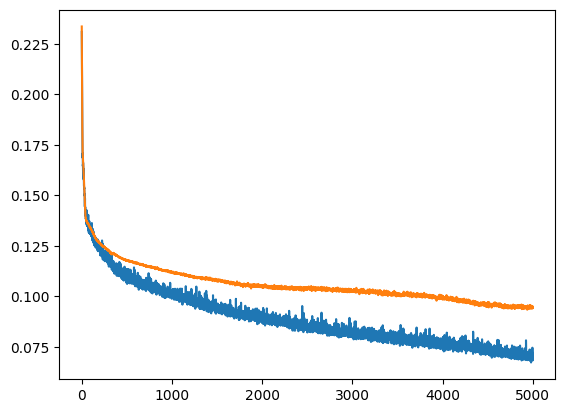

In [30]:
#Documents
#Normalization
#No augmentation
#No keeping one sample together
#4 layers each 8 neurons, custom loss, equal weights
#batch size = 100
#Bigger network (64 neurons max)


plt.plot(train_losses) #real
plt.plot(val_losses) #lr=0.0001

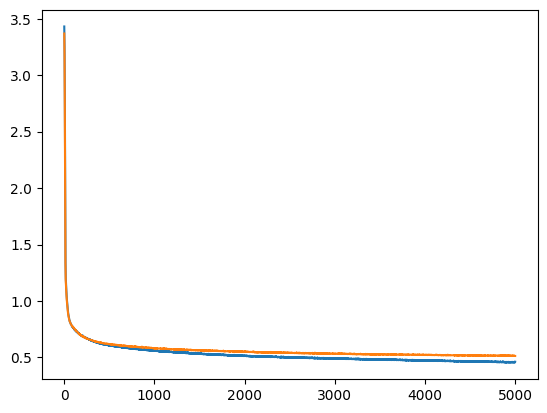

In [31]:
#Documents
#Adjusted log transform
#No augmentation
#No keeping one sample together
#4 layers each 8 neurons, custom loss, equal weights
#batch size = 100
#Bigger network (64 neurons max)


plt.plot(train_losses) #real
plt.plot(val_losses) #lr=0.0001

<IPython.core.display.Javascript object>


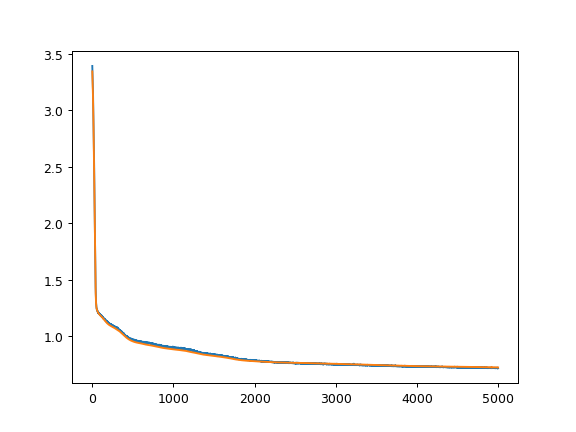

In [34]:
#Documents
#Adjusted log transform
#No augmentation
#No keeping one sample together
#4 layers each 8 neurons, custom loss, equal weights
plt.plot(train_losses) #real
plt.plot(val_losses) #lr=0.0001

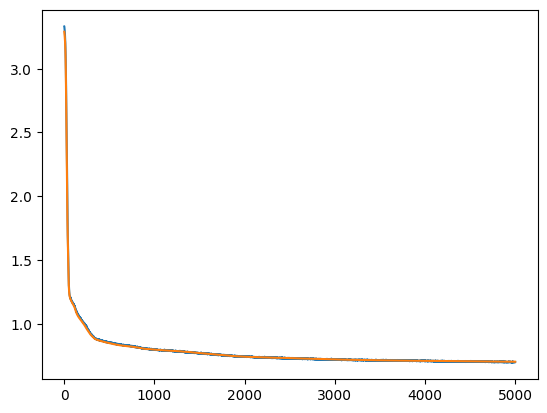

In [30]:
#Documents
#Adjusted log transform
#No augmentation
#No keeping one sample together
#4 layers each 8 neurons, custom loss, equal weights
plt.plot(train_losses) #real
plt.plot(val_losses) #lr=0.0001

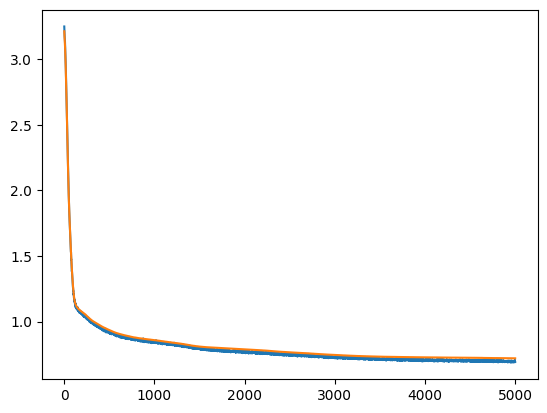

In [31]:
#Adjusted log transform
#No augmentation
#No keeping one sample together
#4 layers each 8 neurons, custom loss, equal weights
plt.plot(train_losses) #real
plt.plot(val_losses) #lr=0.0001

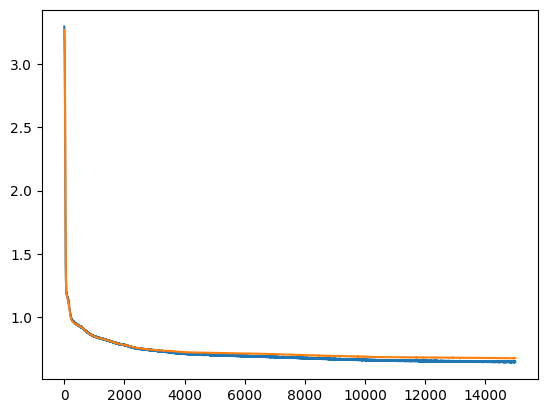

In [35]:
#Adjusted log transform
#No augmentation
#No keeping one sample together
#4 layers each 8 neurons, custom loss, equal weights
plt.plot(train_losses) #real
plt.plot(val_losses) #lr=0.0001

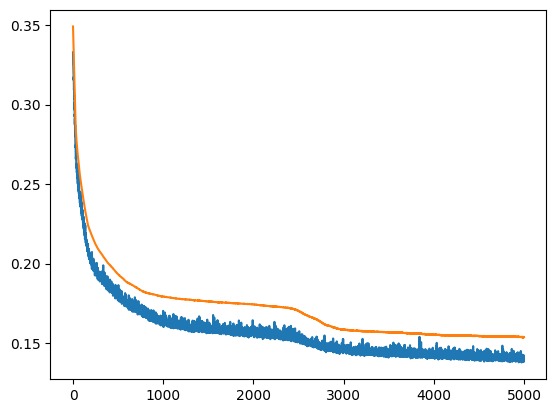

In [34]:
#No augmentation
#No keeping one sample together
#4 layers each 8 neurons, custom loss, weights 1/4, 1/20, 1/20, 1/4, 1/20, 1/4, 1/20, 1/20
plt.plot(train_losses) #real
plt.plot(val_losses) #lr=0.0001

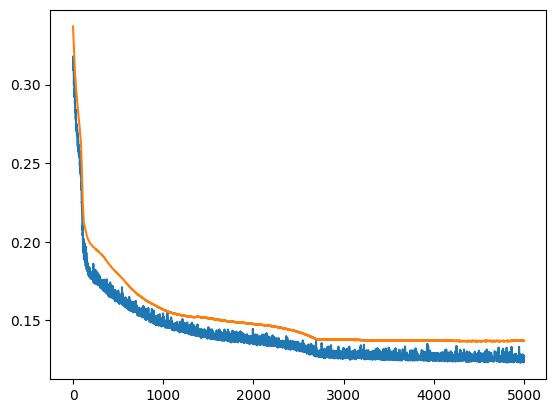

In [33]:
#No augmentation
#No keeping one sample together
#4 layers each 8 neurons, custom loss, weights [1/8, 1/8, ...]
plt.plot(train_losses) #real
plt.plot(val_losses) #lr=0.0001

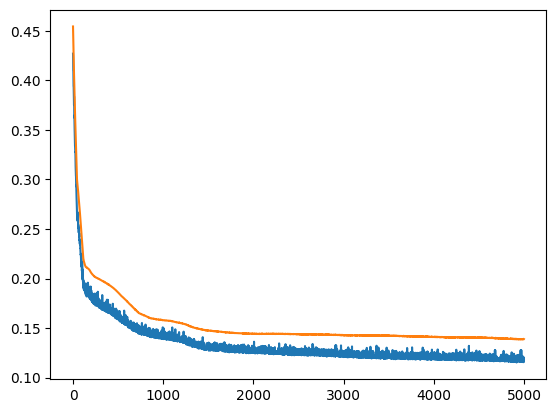

In [33]:
#No augmentation
#No keeping one sample together
#4 layers each 8 neurons, custom loss, weights [1/8, 1/40, ...]
plt.plot(train_losses) #real
plt.plot(val_losses) #lr=0.0001

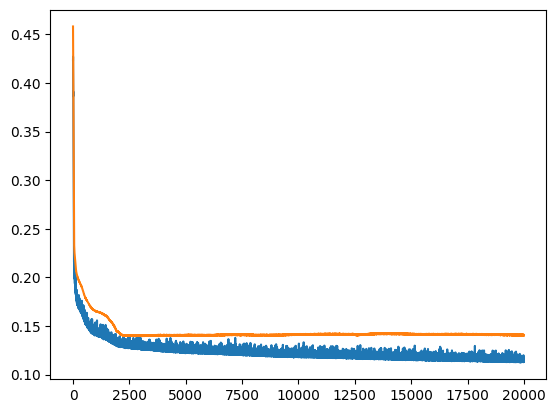

In [33]:
#No augmentation
#No keeping one sample together
#4 layers each 8 neurons, custom loss, weights [1/8, 1/40, ...]
plt.plot(train_losses) #real
plt.plot(val_losses) #lr=0.0001

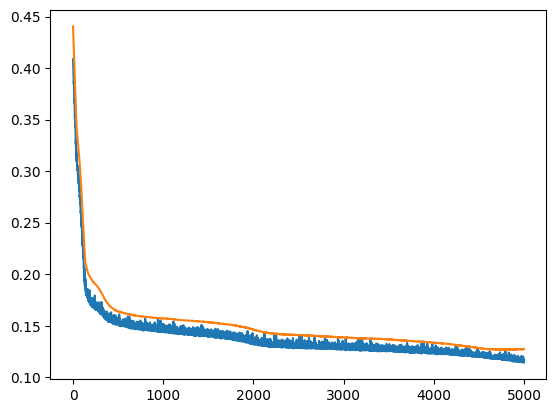

In [33]:
#No augmentation
#No keeping one sample together
#4 layers each 8 neurons, custom loss, weights [1/8, 1/40, ...]
plt.plot(train_losses) #real
plt.plot(val_losses) #lr=0.0001

## Prediction on test set

In [30]:
model.eval()
running_tloss = 0
for i, tdata in enumerate(test_loader):
    inputs, labels = tdata
    outputs = model(inputs)
    loss = loss_fn(outputs, labels)
    if i==0:
        out = outputs
        lab = labels
        res = abs(outputs-labels)
    else:
        res = torch.concat((res, abs(outputs-labels)), axis=0)
        lab = torch.concat((lab, labels), axis=0)
        out = torch.concat((out, outputs), axis=0)
    running_tloss += loss.item()
    
mean_loss = running_tloss/len(test_loader)

Consecutive inks from test set are in lab tensor (484 examples, 8 elements/coordinates):

In [31]:
lab

tensor([[ 0.6814, -3.8429, -7.3168,  ..., -2.0901, -5.5168, -0.8327],
        [ 1.7116, -4.4546, -7.4808,  ..., -1.2107, -5.7975, -1.4870],
        [ 1.7433, -3.2536, -7.8672,  ..., -4.1254, -3.4859, -2.4003],
        ...,
        [ 1.5180, -2.1008, -6.8141,  ..., -3.6722, -4.1360,  0.2913],
        [-0.0894, -3.8682, -7.6653,  ..., -1.7766, -5.5490, -0.9989],
        [-0.3599, -5.9045, -7.8310,  ...,  1.1395, -2.5659, -0.6577]],
       device='cuda:0')

Predictions are in out tensor (484 examples, 8 elements/coordinates):

In [32]:
out

tensor([[ 0.3369, -3.8417, -7.3706,  ..., -1.6079, -5.3610, -0.8437],
        [ 1.8756, -3.8992, -7.5914,  ..., -1.3786, -4.9201, -1.3758],
        [ 1.5856, -3.3224, -7.8165,  ..., -4.1737, -3.3078, -2.4604],
        ...,
        [ 0.0494, -4.3057, -9.5786,  ..., -4.0138, -5.2076,  0.2500],
        [-0.1707, -3.7155, -7.7825,  ..., -1.7415, -5.4985, -1.5839],
        [-0.3985, -5.3736, -8.8138,  ...,  0.9182, -2.8372, -0.5326]],
       device='cuda:0', grad_fn=<CatBackward0>)

Absolute value of difference between true values (lab) and prediction (out) are stored in res tensor (484 examples, 8 elements/coordinates):

In [33]:
res

tensor([[3.4456e-01, 1.1966e-03, 5.3828e-02,  ..., 4.8220e-01, 1.5582e-01,
         1.0952e-02],
        [1.6403e-01, 5.5539e-01, 1.1056e-01,  ..., 1.6795e-01, 8.7738e-01,
         1.1118e-01],
        [1.5767e-01, 6.8780e-02, 5.0747e-02,  ..., 4.8306e-02, 1.7803e-01,
         6.0079e-02],
        ...,
        [1.4685e+00, 2.2049e+00, 2.7645e+00,  ..., 3.4157e-01, 1.0716e+00,
         4.1330e-02],
        [8.1238e-02, 1.5273e-01, 1.1712e-01,  ..., 3.5082e-02, 5.0429e-02,
         5.8505e-01],
        [3.8588e-02, 5.3095e-01, 9.8281e-01,  ..., 2.2132e-01, 2.7129e-01,
         1.2505e-01]], device='cuda:0', grad_fn=<CatBackward0>)

To calculate mean error on consecutive coordinates run:

In [34]:
torch.mean(res, axis=0) 

tensor([0.4113, 0.4165, 0.6024, 0.3236, 0.4170, 0.4053, 0.4493, 0.4387],
       device='cuda:0', grad_fn=<MeanBackward1>)

Consecutive coordinates correspond to: Al, S, Cr, Mn, Co, Cu, Zn, Pb.

Significance of elements: Cu >> Mn > Al > Zn > Pb > S > Cr > Co >> all the others.

Later on we will modify loss function so that errors from coordinates will be weighted depending on the importance of chemical elements.

To calculate mean error on all coordinates run:

In [35]:
torch.mean(res)

tensor(0.4330, device='cuda:0', grad_fn=<MeanBackward0>)

## Saving the model

In [36]:
import time
ts = time.time()
import datetime
now = datetime.datetime.fromtimestamp(ts).strftime('%Y_%m_%d_%H_%M_%S')

torch.save(model.state_dict(), models_path[object_name]+'model_regression_'+now)

### Visualisations

In [37]:
dim_nr = 7
selected_outputs = out[:, dim_nr].cpu().detach().numpy()
selected_labels = lab[:, dim_nr].cpu().detach().numpy()

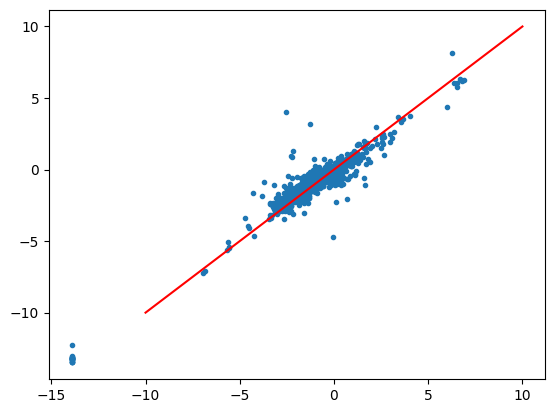

In [38]:
plt.plot(selected_labels, selected_outputs, '.')
plt.plot( [-10, 10],[-10, 10], 'red' )

## Quality of prediction: closest points

#### Creating df with means of classes

In [39]:
elements_names = [el.split('_')[0] for el in columns_to_keep_inds[object_name]]

In [40]:
train_val_df = pd.DataFrame(y_train.cpu())
train_val_df = pd.concat([train_val_df, 
                                    pd.DataFrame(y_val.cpu())])
train_val_df.columns = elements_names
train_val_df.insert(0, 'Sample_id', pd.concat([train_order, val_order]))
train_val_df.reset_index(drop=True, inplace=True)

In [41]:
mean_df = train_val_df[['Sample_id']]

for name in elements_names:
    mean_df[name] = train_val_df.groupby('Sample_id')[name].transform('mean')
    mean_df.drop_duplicates('Sample_id', inplace=True)
    
mean_df.sort_values(by='Sample_id', inplace=True)
mean_df.reset_index(drop=True, inplace=True)

/tmp/ipykernel_7841/649964028.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  mean_df[name] = train_val_df.groupby('Sample_id')[name].transform('mean')
/tmp/ipykernel_7841/649964028.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  mean_df.drop_duplicates('Sample_id', inplace=True)
/tmp/ipykernel_7841/649964028.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/i

#### Checking if there is any chance for it to work: if classes in y_test are close to means of classes in train_val set

In [42]:
y_test_df = pd.DataFrame(y_test.cpu())
y_test_df.columns = elements_names
y_test_df.insert(0, 'Sample_id', test_order)
y_test_df.reset_index(drop=True, inplace=True)

In [43]:
closest = []
for i in range(y_test_df.shape[0]):
    which_row = (abs(y_test_df.iloc[i, 1:] - mean_df.iloc[:,1:])).sum(1).idxmin()
    closest.append(mean_df.iloc[which_row]['Sample_id'])

In [44]:
len(closest)

780

In [45]:
y_test_df['Closest'] = closest

In [46]:
y_test_df[y_test_df['Sample_id'] == y_test_df['Closest']].shape[0] 

724

In [47]:
y_test_df[y_test_df['Sample_id'] == y_test_df['Closest']].shape[0] / len(closest)

0.9282051282051282

#### Now let's check if it works for the neural network's output.

In [48]:
model.eval()
outputs = model(X_test)

In [49]:
outputs_df = pd.DataFrame(outputs.cpu().detach().numpy())
outputs_df.columns = elements_names
outputs_df.insert(0, 'Real sample_id', test_order)
outputs_df.reset_index(drop=True, inplace=True)

In [50]:
closest = []
for i in range(outputs_df.shape[0]):
    which_row = (abs(outputs_df.iloc[i, 1:] - mean_df.iloc[:,1:])).sum(1).idxmin()
    closest.append(mean_df.iloc[which_row]['Sample_id'])

In [51]:
len(closest)

780

In [52]:
outputs_df['Closest'] = closest

In [53]:
outputs_df[y_test_df['Sample_id'] == outputs_df['Closest']].shape[0]

420

In [54]:
outputs_df[y_test_df['Sample_id'] == outputs_df['Closest']].shape[0] / len(closest)

0.5384615384615384

## Quality of prediction: confidence intervals

In [55]:
model.eval()
outputs = model(X_test)

In [56]:
elements_names = [el.split('_')[0] for el in columns_to_keep_inds[object_name]]

In [57]:
all_data_df = pd.DataFrame(y_train.cpu())
all_data_df = pd.concat([all_data_df, 
                        pd.DataFrame(y_val.cpu())])
all_data_df.columns = elements_names
all_data_df.insert(0, 'Sample_id', pd.concat([train_order, val_order]))
all_data_df.reset_index(drop=True, inplace=True)

In [58]:
min_max_df = all_data_df[['Sample_id']]

for name in elements_names:
    min_max_df[name + '_max'] = all_data_df.groupby('Sample_id')[name].transform('max')
    min_max_df.drop_duplicates('Sample_id', inplace=True)
    
for name in elements_names:
    min_max_df[name + '_min'] = all_data_df.groupby('Sample_id')[name].transform('min')
    min_max_df.drop_duplicates('Sample_id', inplace=True)
        
min_max_df.sort_values(by='Sample_id', inplace=True)
min_max_df.reset_index(drop=True, inplace=True)

max_df = min_max_df.iloc[:,1:(1+len(elements_names))]
max_df['Sample_id'] = min_max_df['Sample_id']
min_df = min_max_df.iloc[:,1+len(elements_names):]
min_df['Sample_id'] = min_max_df['Sample_id']

/tmp/ipykernel_7841/3264826654.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  min_max_df[name + '_max'] = all_data_df.groupby('Sample_id')[name].transform('max')
/tmp/ipykernel_7841/3264826654.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  min_max_df.drop_duplicates('Sample_id', inplace=True)
/tmp/ipykernel_7841/3264826654.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/sta

In [59]:
mean_sd_df = all_data_df[['Sample_id']]

for name in elements_names:
    mean_sd_df[name + '_mean'] = all_data_df.groupby('Sample_id')[name].transform('mean')
    mean_sd_df.drop_duplicates('Sample_id', inplace=True)
    
for name in elements_names:
    mean_sd_df[name + '_sd'] = all_data_df.groupby('Sample_id')[name].transform(np.std)
    mean_sd_df.drop_duplicates('Sample_id', inplace=True)
    
mean_sd_df.sort_values(by='Sample_id', inplace=True)
mean_sd_df.reset_index(drop=True, inplace=True)

upper_bound_df = mean_sd_df.iloc[:,1:(1+len(elements_names))].values + \
                2*mean_sd_df.iloc[:,1+len(elements_names):].values
upper_bound_df = pd.DataFrame(upper_bound_df, columns=elements_names)
upper_bound_df['Sample_id'] = mean_sd_df[['Sample_id']]

lower_bound_df = mean_sd_df.iloc[:,1:(1+len(elements_names))].values - \
                2*mean_sd_df.iloc[:,1+len(elements_names):].values
lower_bound_df = pd.DataFrame(lower_bound_df, columns=elements_names)
lower_bound_df['Sample_id'] = mean_sd_df[['Sample_id']]

/tmp/ipykernel_7841/2008320981.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  mean_sd_df[name + '_mean'] = all_data_df.groupby('Sample_id')[name].transform('mean')
/tmp/ipykernel_7841/2008320981.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  mean_sd_df.drop_duplicates('Sample_id', inplace=True)
/tmp/ipykernel_7841/2008320981.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/s

In [60]:
min_max_res_list = []
for test_example, sample_id in zip(outputs, test_order):
    
    greater_than_min = test_example.cpu().detach().numpy() > \
                    np.array(min_df.loc[min_df['Sample_id'] == sample_id, min_df.columns != 'Sample_id'])
    
    less_than_max = test_example.cpu().detach().numpy() < \
                    np.array(max_df.loc[max_df['Sample_id'] == sample_id, max_df.columns != 'Sample_id'])
    
    res = np.logical_and(greater_than_min, less_than_max)
    
    #print(res)
    min_max_res_list.append(res)

In [61]:
sd_res_list = []
for test_example, sample_id in zip(outputs, test_order):
    
    greater = test_example.cpu().detach().numpy() > \
    np.array(lower_bound_df.loc[lower_bound_df['Sample_id'] == sample_id, lower_bound_df.columns != 'Sample_id'])
    
    less = test_example.cpu().detach().numpy() < \
    np.array(upper_bound_df.loc[upper_bound_df['Sample_id'] == sample_id, upper_bound_df.columns != 'Sample_id'])
    
    res = np.logical_and(greater, less)
    
    #print(res)
    sd_res_list.append(res)

In [62]:
elements_names

['Al', 'S', 'Cr', 'Mn', 'Co', 'Cu', 'Zn', 'Pb']

Percentage of points inside mean +- 2 standard deviations interval:

In [63]:
np.array(sd_res_list).mean()

0.5088141025641025

On consecutive coordinates:

In [64]:
np.array(sd_res_list).mean(0)

array([[0.58846154, 0.54102564, 0.67820513, 0.40128205, 0.38846154,
        0.44230769, 0.50641026, 0.52435897]])

Percentage of points inside min-max interval:

In [65]:
np.array(min_max_res_list).mean()

0.4288461538461538

On consecutive coordinates:

In [66]:
np.array(min_max_res_list).mean(0)

array([[0.49615385, 0.45897436, 0.61282051, 0.31282051, 0.31410256,
        0.37179487, 0.43205128, 0.43205128]])

### Visualisations of mean +- 2 * standard deviation intervals

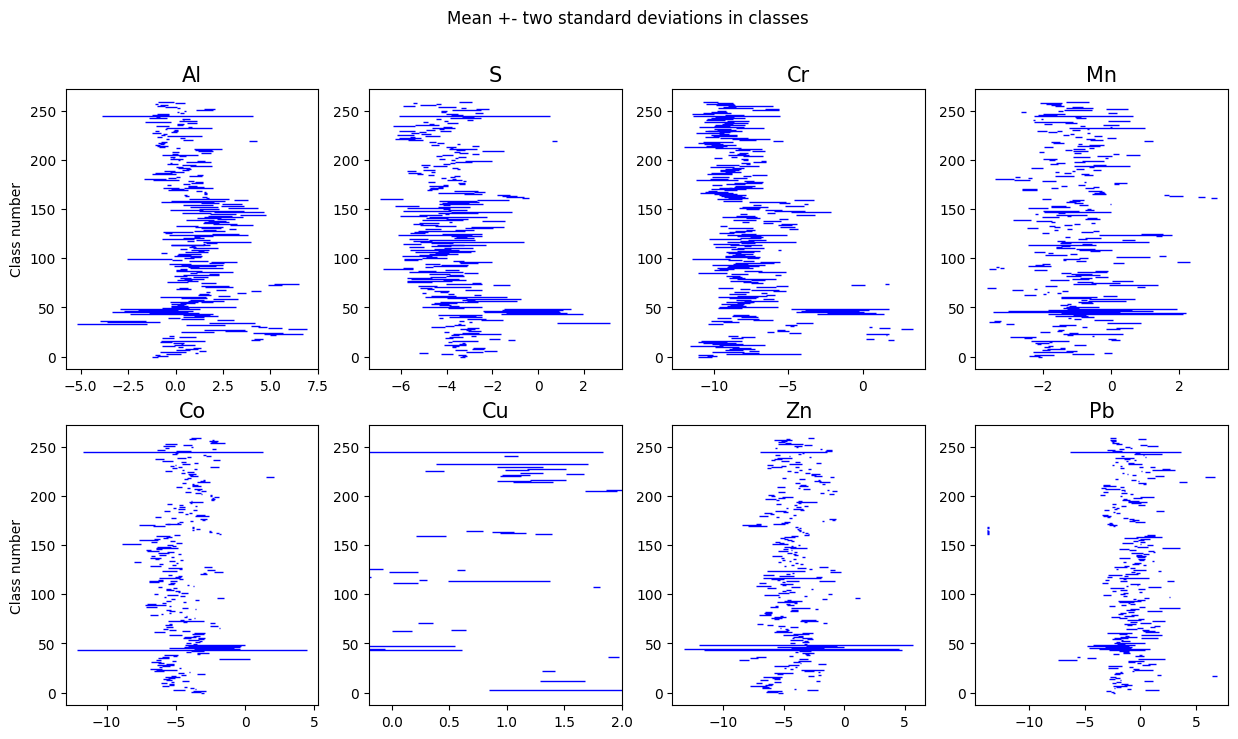

In [67]:
fig, ax = plt.subplots(2,4, figsize=(15,8))
plt.suptitle('Mean +- two standard deviations in classes')
for sample_id in range(min_max_df.shape[0]):
    for element in range(int((min_max_df.shape[1]-1)/2)):
        ax[element//4][element%4].hlines(y=sample_id, xmin=lower_bound_df.iloc[sample_id, element], 
                  xmax=upper_bound_df.iloc[sample_id, element], 
                  color="blue", linewidth=1)
        ax[element//4][element%4].set_title(elements_names[element], size=15)
        if element == 5:
            ax[element//4][element%4].set_xlim([-0.2, 2.0])
        if element == 0 or element == 4:
            ax[element//4][element%4].set_ylabel('Class number')
#plt.savefig(figures_path + 'intervals.png', dpi=300)

### Visualisations of min-max intervals

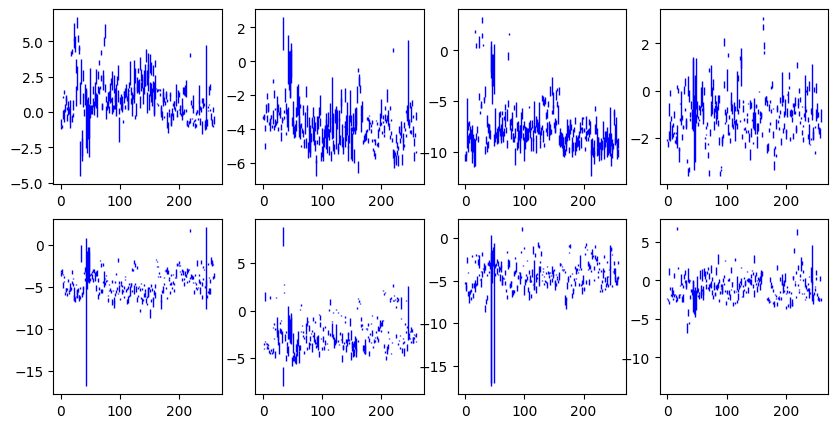

In [68]:
fig, ax = plt.subplots(2,4, figsize=(10,5))
for sample_id in range(min_max_df.shape[0]):
    for element in range(int((min_max_df.shape[1]-1)/2)):
        ax[element//4][element%4].vlines(x=sample_id, ymin=min_max_df.iloc[sample_id, element+9], 
                  ymax=min_max_df.iloc[sample_id, element+1], 
                  color="blue", linewidth=1)
        #ax[element%4][element%2].set_title(elements_names[element])

For a single element:

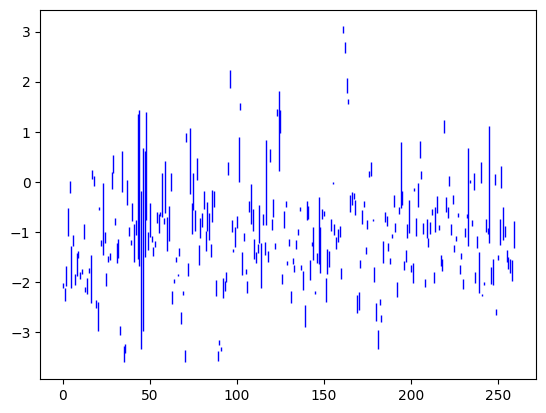

In [69]:
element = 3
for sample_id in range(min_max_df.shape[0]):
    plt.vlines(x=sample_id, ymin=min_max_df.iloc[sample_id, element+9], 
                  ymax=min_max_df.iloc[sample_id, element+1], 
                  color="blue", linewidth=1)

## Interpretability